# A52 Dipanshu Ambilkar

## Practical 4 - K-Means clustering on the Iris dataset

In [1]:
# A52 Dipanshu Ambilkar
"""
Practical 4 - K-Means clustering on the Iris dataset (simple version)
Requirement: cluster the data and choose the number of clusters
with the elbow method.
"""
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [2]:
# 1. Load data (we ignore the species labels while clustering)
X, species = load_iris(return_X_y=True)
print("Shape:", X.shape)


Shape: (150, 4)


Inertias for k=1..10: [681, 152, 79, 57, 46, 39, 34, 30, 28, 26]


Plot saved: elbow.png


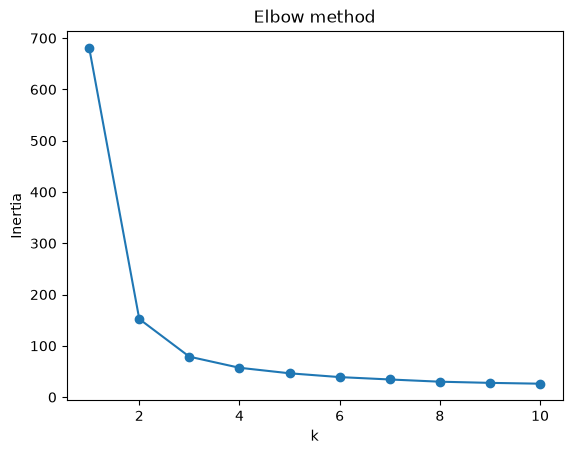

In [3]:
# 2. Elbow method: inertia for k = 1..10
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=7)
    km.fit(X)
    inertias.append(km.inertia_)
print("Inertias for k=1..10:", [round(v) for v in inertias])

plt.plot(range(1, 11), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.savefig("elbow.png")
print("Plot saved: elbow.png")


In [4]:
# 3. The elbow is at k=3 (iris has 3 species), so cluster with k=3
km = KMeans(n_clusters=3, n_init=10, random_state=7)
labels = km.fit_predict(X)
print("\nCluster sizes:", [sum(labels == c) for c in range(3)])



Cluster sizes: [np.int64(50), np.int64(62), np.int64(38)]


In [5]:
# 4. Quick check: how pure are the clusters?
for c in range(3):
    counts = [sum((labels == c) & (species == s)) for s in range(3)]
    print(f"Cluster {c}: species counts {counts}")


Cluster 0: species counts [np.int64(50), np.int64(0), np.int64(0)]
Cluster 1: species counts [np.int64(0), np.int64(48), np.int64(14)]
Cluster 2: species counts [np.int64(0), np.int64(2), np.int64(36)]
